# BattMo Workshop

The workshop consists of the following parts:
- **Hello BattMo**: a short introduction to BattMo.jl
- **Thermal modelling**: explore the thermal model in BattMo.jl and use the by the dS-Toolbox computed entropy coefficient to improve our thermal results

##### Import packages

In [78]:
using BattMo, PlotlyJS, Jutul, CSV, DataFrames

## Hello BattMo

Welcome to this hands-on tutorial where we’ll explore the basics of BattMo.jl — a powerful Julia package for simulating lithium-ion battery cells using physics-based models like the Doyle-Fuller-Newman (DFN) model. 

By the end of this part of the tutorial, you’ll:

- Understand some basic features of BattMo.jl
- Run your first battery simulation
- Explore and visualize the output
- Learn how to tweak key parameters for custom behavior

#### Input format

BattMo.jl structures its simulation inputs into two primary categories: Parameters and Settings. This distinction helps users differentiate between the physical characteristics of the battery system and the numerical configurations of the simulation.

**Parameters** represent the controllable variables in real-world experiments. They are further divided into:

- **Cell Parameters**: define the intrinsic properties of the battery cell, such as geometry and material characteristics.
- **Cycling Protocol Parameters**: specify how the cell is operated during a simulation.

**Settings** are used to configure numerical assumptions for solving equations and finding numerical solutions. They are further divided into:

- **Model Settings**: define numerical assumptions related to the battery model, such as diffusion methods or simplifications used in the simulation.
- **Simulation Settings**: define numerical assumptions specific to the simulation process, including time-stepping schemes and discretization precision.
- **Solver Settings**: define solver behavior and verbosity.

**BattMo** stores cell parameters, cycling protocols and settings in a user-friendly JSON format to facilitate reuse.

#### Load and modify input files

In [5]:
include("./input_files/function_parameters_xu_2015.jl")

cell_parameters = load_cell_parameters(; from_file_path = "input_files/cell_parameters.json");
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json");

In [13]:
print_info(cell_parameters)


PARAMETER OVERVIEW
Parameter                                                                                 Unit                Type                Value                         
----------------------------------------------------------------------------------------------------------------------------------------------------------------
[ "Cell" ][ "Case" ]                                                                      N/A                 String              Pouch                         
[ "Cell" ][ "DoubleCoatedElectrodes" ]                                                    -                   Bool                false                         
[ "Cell" ][ "ElectrodeGeometricSurfaceArea" ]                                             m²                  Float64             0.00668                       
[ "Cell" ][ "ElectrodeLength" ]                                                           m                   Float64             0.1                           
[ "Cell" ][ "E

To change cell parameters, we can modify the JSON files directly, or we can read them into objects in the script and modify them as Dictionaries. A loaded cell parameter set is a Dictionary-like object which come with additional handy functions like the `print_info` we just used.

Parameters that take single numerical values (e.g. real, integers, booleans) can be directly modified.

In [14]:
cell_parameters["PositiveElectrode"]["Coating"]["Thickness"] = 92.0e-6

9.2e-5

Some parameters are described as functions or arrays, since the parameter value depends on other variables. For instance the Open Circuit Potentials of the Active Materials depend on the lithium stoichiometry and temperature. When we're unsure about the type or meaning of a parameter, we can print information on invidual parameters as well. For some parameters, that require more explanation, a link to the documentation is provided. Visit the documentation of the OpenCircuitPotential parameter to find more information on how to implement you own user defined functional parameters.

In [15]:
parameter_name = "OpenCircuitPotential"

print_info(parameter_name, view = "CellParameters")


----------------------------------------------------------------------------------------------------
🔋  Cell Parameter:  OpenCircuitPotential
----------------------------------------------------------------------------------------------------
    🔹 Name               OpenCircuitPotential
    🔹 Category           CellParameters
    🔹 Description        The open-circuit potential of the active material under a given intercalant stoichimetry and temperature.
    🔹 Type               String, Dict{String, Vector}, Real
    🔹 Unit               V
    🔹 Documentation      [visit](https://battmo.org/BattMo.jl/dev/manuals/user_guide/simulation_dependent_input)

    🔹 Ontology link      [visit](https://w3id.org/emmo/domain/electrochemistry#electrochemistry_9c657fdc_b9d3_4964_907c_f9a6e8c5f52b)




The cycling protocol parameters and the settings (model settings, simulation settings, solver settings) can be loaded, viewed and altered in the same way as the cell parameters. Let's load the CC discharge protocol that we have in our input files. The settings we'll go into later.

In [16]:
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json");
print_info(cycling_protocol)


PARAMETER OVERVIEW
Parameter                                                                                 Unit                Type                Value                         
----------------------------------------------------------------------------------------------------------------------------------------------------------------
[ "DRate" ]                                                                               1                   Float64             0.5                           
[ "InitialControl" ]                                                                      N/A                 String              discharging                   
[ "InitialStateOfCharge" ]                                                                1                   Float64             0.99                          
[ "LowerVoltageLimit" ]                                                                   V                   Float64             2.5                           
[ "Protocol" ]

In [17]:

quick_cell_check(cell_parameters)

════════════════════════════════════════════════════════════════════════════════════════════════════════════
🔋 Quick Cell Check
════════════════════════════════════════════════════════════════════════════════════════════════════════════
Cell 1: Xu2015

Quantity                                Cell 1         | Unit         | Source
────────────────────────────────────────────────────────────────────────────────────────────────────────────
Nominal Voltage                         3.2            | V            | [INPUT]     
Nominal Capacity                        16.5           | Ah           | [INPUT]     
Cell Theoretical Capacity               0.1551         | Ah           | [EQUILIBRIUM CALCULATION]
Cell N:P Ratio                          0.8985         | -            | [EQUILIBRIUM CALCULATION]
Cell Mass                               0.002439       | kg           | [EQUILIBRIUM CALCULATION]
Positive Electrode Mass Loading         14.8           | mg/cm²       | [EQUILIBRIUM CALCULATIO

#### Run a simulation

In this part we'll show how you can run a simple P2D simulation. Let's start by loading the Xu 2015 cell parameter set and a constant current discharge cycling protocol.

In [18]:
cell_parameters = load_cell_parameters(; from_file_path = "input_files/cell_parameters.json");
cycling_protocol = load_cycling_protocol(; from_file_path = "input_files/cc_discharge.json");

Next, we select the default Lithium-Ion Battery model. A model can be thought as a mathematical implementation of the electrochemical and transport phenomena occuring in a real battery cell. The implementation consist of a system of partial differential equations and their corresponding parameters, constants and boundary conditions. The default Lithium-Ion Battery setup selected below contains the model settings to simulate a basic P2D model, where neither current collectors nor SEI growth are considered.

In [19]:
model = LithiumIonBattery();

✔️ Validation of ModelSettings passed: No issues found.
──────────────────────────────────────────────────


The LithiumIonBattery constructor validates the model settings on the back ground. If the model setup is valid we can continue and create a Simulation object by passing the model setup, cell parameters and a cycling protocol.

In [20]:
sim = Simulation(model, cell_parameters, cycling_protocol);

✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────


The simulation object is only instantiated when the model provided is valid. We can see that the Simulation object also validates the parameters and settings on the back ground. Each parameter set is validated on whether they are sensible and complete. 

When the Simulation object is valid we can solve the simulation by passing the object to the solve function. As Julia is a compiled language, the first time that we run a simulation it will take some time to compile the functions and structs that it encounters. This makes running a second simulation very fast. See the difference by running the script for a second time.

In [21]:
output = solve(sim);

✔️ Validation of SolverSettings passed: No issues found.
──────────────────────────────────────────────────
Jutul: Simulating 2 hours, 12 minutes as 163 report steps


Progress   1%|█                                          |  ETA: 0:10:22

Progress   3%|██                                         |  ETA: 0:04:08

Progress   9%|████                                       |  ETA: 0:01:19

Progress  15%|███████                                    |  ETA: 0:00:47

Progress  21%|█████████                                  |  ETA: 0:00:31

Progress  26%|████████████                               |  ETA: 0:00:24

Progress  30%|██████████████                             |  ETA: 0:00:19

Progress  36%|████████████████                           |  ETA: 0:00:15

Progress  41%|██████████████████                         |  ETA: 0:00:12

Progress  48%|█████████████████████                      |  ETA: 0:00:09

Progress  55%|████████████████████████                   |  ETA: 0:00:07

Progress  60%|██████████████████████████                 |  ETA: 0:00:06

Progress  65%|█████████████████████████████              |  ETA: 0:00:05

Progress  70%|████████████████████████

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 137 steps │ 137 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   2.36496 │       2.36496 │  324 (0) │
│ Linearization  │   3.36496 │       3.36496 │  461 (0) │
│ Linear solver  │   2.36496 │       2.36496 │  324 (0) │
│ Precond apply  │       0.0 │           0.0 │    0 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬─────────┬────────────┬────────╮
│ Timing type   │    Each │   Relative │  Total │
│               │      ms │ Percentage │      s │
├───────────────┼─────────┼────────────┼────────┤
│ Properties    │  0.7151 │     2.44 % │ 0.2317 │
│ Equations     │  1.8595 │     9.02 % │ 0.8572 │
│ Assembly      │  1.9405 │     9.41 % │ 0.8946 │
│ Linear solve  │  1.1613 │     3.96 % │ 0.3763 │
│ Linear setup  │  0.0000 │     0.00 % │ 0.0000 │
│ Precond apply │  0.0000 │ 

In [49]:
output.states["NegativeElectrode"]["ActiveMaterial"]["Position"]

10-element Vector{Float64}:
 3.250000000000001e-6
 9.750000000000002e-6
 1.6250000000000002e-5
 2.275e-5
 2.925000000000001e-5
 3.575000000000001e-5
 4.225000000000002e-5
 4.875e-5
 5.525000000000001e-5
 6.175e-5

We can use some built in functions for quick plotting. The dashboard gives you a quick overview of some important ouput variables. You can choose to have interactive line plots where you can change the time step using a slider or contour plots that show the position and time in one plot.

In [47]:
using PlotlyJS
using PlotlyBase: Spec

function plot_dashboard_plotly(output; plot_type="simple")

    ts = output.time_series
    t = ts["Time"] ./ si_unit("hour")
    I = ts["Current"]
    E = ts["Voltage"]

    # =======================
    # SIMPLE
    # =======================
    if plot_type == "simple"

        fig = make_subplots(
            rows=2, cols=1,
            shared_xaxes=true,
            subplot_titles=reshape(["Current / A", "Voltage / V"], 2, 1)
        )

        add_trace!(fig, PlotlyJS.scatter(x=t, y=I, mode="lines+markers"), row=1, col=1)
        add_trace!(fig, PlotlyJS.scatter(x=t, y=E, mode="lines+markers"), row=2, col=1)

        # ✅ Labels only (no ranges!)
        relayout!(fig,
            xaxis_title="Time / h",
            yaxis_title="Current / A",
            xaxis2_title="Time / h",
            yaxis2_title="Voltage / V"
        )

        return fig
    end


    # =======================
    # CONTOUR
    # =======================
    if plot_type == "contour"

        states = output.states

        specs = [
            [Spec(colspan=3) Spec() Spec()];
            [Spec(colspan=3) Spec() Spec()];
            [Spec()          Spec() Spec()];
            [Spec()          Spec() Spec()]
        ]

        subplot_titles = reshape([
            "Current / A", "", "",
            "Voltage / V", "", "",
            "NeAm Conc", "Elyte Conc", "PeAm Conc",
            "NeAm Pot",  "Elyte Pot",  "PeAm Pot"
        ], 4, 3)

        fig = make_subplots(
            rows=4, cols=3,
            specs=specs,
            subplot_titles=subplot_titles,
            row_heights=[0.22, 0.22, 0.28, 0.28],
            vertical_spacing=0.08,
            horizontal_spacing=0.05
        )

        # =========================
        # ✅ TOP PLOTS (FULL WIDTH)
        # =========================
        add_trace!(fig,
            PlotlyJS.scatter(x=t, y=I, mode="lines", line=attr(width=3)),
            row=1, col=1
        )

        add_trace!(fig,
            PlotlyJS.scatter(x=t, y=E, mode="lines", line=attr(width=3)),
            row=2, col=1
        )

        # ✅ Only labels (NO ranges!)
        relayout!(fig,
            xaxis_title="Time / h",
            yaxis_title="Current / A",

            xaxis4_title="Time / h",
            yaxis4_title="Voltage / V"
        )

        # =========================
        # ✅ CONTOUR HELPER
        # =========================
        function add_contour!(row, col, position, data)
            x, Z, x_label = dashboard_profile(states, position, data)

            add_trace!(fig,
                PlotlyJS.contour(
                    x=x,
                    y=t,
                    z=Z',
                    colorscale="Viridis",
                    showscale=false   # cleaner layout
                ),
                row=row, col=col
            )

            return x_label
        end

        # =========================
        # ✅ ROW 3
        # =========================
        xl1 = add_contour!(3,1,
            states["NegativeElectrode"]["ActiveMaterial"]["Position"],
            states["NegativeElectrode"]["ActiveMaterial"]["SurfaceConcentration"])

        xl2 = add_contour!(3,2,
            states["Electrolyte"]["Position"],
            states["Electrolyte"]["Concentration"])

        xl3 = add_contour!(3,3,
            states["PositiveElectrode"]["ActiveMaterial"]["Position"],
            states["PositiveElectrode"]["ActiveMaterial"]["SurfaceConcentration"])

        # =========================
        # ✅ ROW 4
        # =========================
        xl4 = add_contour!(4,1,
            states["NegativeElectrode"]["ActiveMaterial"]["Position"],
            states["NegativeElectrode"]["ActiveMaterial"]["Potential"])

        xl5 = add_contour!(4,2,
            states["Electrolyte"]["Position"],
            states["Electrolyte"]["Potential"])

        xl6 = add_contour!(4,3,
            states["PositiveElectrode"]["ActiveMaterial"]["Position"],
            states["PositiveElectrode"]["ActiveMaterial"]["Potential"])

        # =========================
        # ✅ AXIS LABELS ONLY
        # =========================
        relayout!(fig,

            # Row 3
            xaxis7_title=xl1,  yaxis7_title="Time / h",
            xaxis8_title=xl2,  yaxis8_title="Time / h",
            xaxis9_title=xl3,  yaxis9_title="Time / h",

            # Row 4
            xaxis10_title=xl4, yaxis10_title="Time / h",
            xaxis11_title=xl5, yaxis11_title="Time / h",
            xaxis12_title=xl6, yaxis12_title="Time / h"
        )

        # ✅ clean margins + size
        relayout!(fig,
            height=1100,
            width=1200,
            margin=attr(l=50, r=20, t=60, b=40),
            title="Contour Dashboard"
        )

        return fig
    end

    error("Unsupported plot_type")
end


# =======================
# DASHBOARD PROFILE
# =======================
function dashboard_profile(states, position, data)
    if haskey(states, "Cell") && haskey(states["Cell"], "Position")
        cell_position = states["Cell"]["Position"]
        if cell_position isa AbstractVector && size(data, 2) == length(cell_position)
            return (cell_position .* 1e6, data, "Position / μm")
        end
    end

    if position isa AbstractVector && size(data, 2) == length(position)
        return (position .* 1e6, data, "Position / μm")
    end

    x = collect(1:size(data, 2))
    return (x, data, "Index")
end

dashboard_profile (generic function with 1 method)

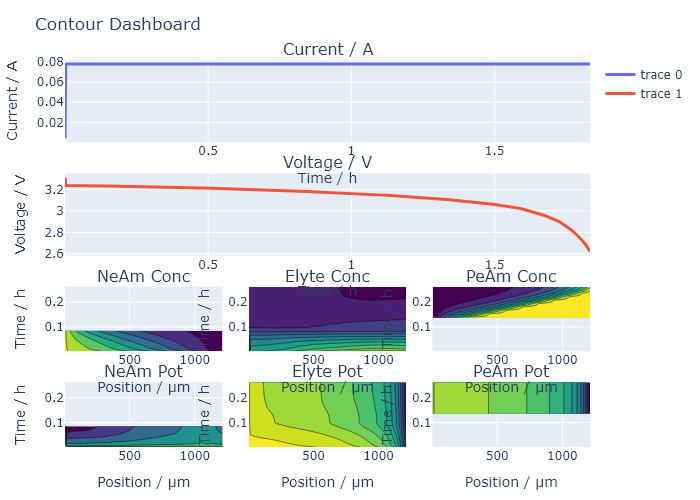

In [48]:
plot_dashboard_plotly(output; plot_type = "contour")

## Thermal Modelling

Now we have run a simulation! But what kind of models did we use during this simulation. The submodels that are activated are specified withint the model. Let's have a look what the model that we instantiated earlier contains.

In [12]:
model.settings

{
    "ButlerVolmer" => "Standard"
    "RampUp" => "Sinusoidal"
    "Metadata" =>     {
        "Description" => "Default model settings for a P2D simulation including a current ramp up, excluding current collectors and SEI effects."
        "Title" => "p2d"
    }
    "PotentialFlowDiscretization" => "GeneralAD"
    "TransportInSolid" => "FullDiffusion"
    "ModelFramework" => "P2D"
}

We can see that it contains a couple of submodel settings. We can see that we ran a P2D simulation, and that's it, not more special than that. The purpose of this tutorial is to show how we can do thermal modelling using BattMo, so let's specify in the model that we want to include the thermal model. To do this we can directly alter the model.

In [13]:
model.settings["ThermalModel"] = "Sequential"

"Sequential"

BattMo.jl has two types of thermal models implemented at the moment: decoupled and sequential. Within the decoupled one, the thermal model is simulated only after the electrochemical simulation is fully finished, while the sequential model updates the thermal simulation at every time step after the electrochemical state has ben computed. For this workshop we'll use the sequential model.

In order to get an accurate representation of the thermal effects within a cell we need to run the simulation on a 3D geometry instead of a 1D. So, let's also specify in the model that we want to do a P4D simulation instead of P2D. Furthermore, do we estimate the prismated cell described in Xu 2015 as a pouch cell.

In [14]:
model.settings["ModelFramework"] = "P4D Pouch"

"P4D Pouch"

Instead of modifying the model instance directly, for clearity and repeatability, it's better to setup your own model_settings input file and pass that to the battery model of choice.

In [67]:
model_settings = load_model_settings(; from_file_path = "input_files/model_settings.json")

model_settings["ModelFramework"] = "P4D Pouch"
model_settings["ThermalModel"] = "Sequential"

model = LithiumIonBattery(;model_settings);

✔️ Validation of ModelSettings passed: No issues found.
──────────────────────────────────────────────────


Before we solve the simulation, let's have a look at the 3D geometry that we're simulating

In order to run a thermal simulation, our parameters need to be adapted. Some of the parameters, like for example, the open circuit potential, the diffusion coefficient, and reaction rate constant have been found to be significantly dependent on the temperature. In order to make our OCP, diffucion coefficient, and reaction rate constant input parameters temperature dependent, we need the entropy coeffient computed in the previous tutorial of dS-Toolbox.

Let's have a look at these input values and how they are setup right now.

Let's load the entropy coefficient data from the dS-Toolbox

In [68]:
# 1. Read data
path = joinpath(pwd(), "../data","BattMo_dUdT.csv")
df = CSV.read(path, DataFrame)

soc = df[:, 1]
entropy_change = df[:, 2];


We can interpolate the data and return the interpolation within a function.

In [69]:
# 2. Use a Jutul interpolator to create an interpolation object of the time and power data
entropy_intp = Jutul.get_1d_interpolator(soc, entropy_change, cap_endpoints = false)


# 3. Define a function to calculate the entropy change.
function entropy_change_function(c, T, refT, cmax)
    
	return entropy_intp(c/cmax)
end


entropy_change_function (generic function with 1 method)

Now we have to let BattMo.jl now that we want it to compute the entropy change using this function. To do this we add the name of the function to the cell parameters input file.

In [70]:
cell_parameters["PositiveElectrode"]["ActiveMaterial"]["EntropyChange"] = Dict(
    "FunctionName" => "entropy_change_function",
)

cell_parameters["NegativeElectrode"]["ActiveMaterial"]["EntropyChange"] = Dict(
    "FunctionName" => "entropy_change_function",
)

Dict{String, String} with 1 entry:
  "FunctionName" => "entropy_change_function"

In [71]:
cycling_protocol["InitialTemperature"] = 298.15
cycling_protocol["AmbientTemperature"] = 298.15

298.15

Now we can finaly run the thermal simulation

In [79]:
sim_thermal = Simulation(model, cell_parameters, cycling_protocol);

couplings = sim_thermal.couplings
coup = couplings["NegativeElectrodeActiveMaterial"]
println(keys(coup))

# output_thermal = solve(sim_thermal);

✔️ Validation of CellParameters passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of CyclingProtocol passed: No issues found.
──────────────────────────────────────────────────
✔️ Validation of SimulationSettings passed: No issues found.
──────────────────────────────────────────────────


KeyError: KeyError: key "External" not found

Let's make some nice plots to visualize the results